In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('./data/bike_train.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1020.7 KB


In [3]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [4]:
df['datetime2'] = pd.to_datetime(df['datetime'])
df['datetime2']

0       2011-01-01 00:00:00
1       2011-01-01 01:00:00
2       2011-01-01 02:00:00
3       2011-01-01 03:00:00
4       2011-01-01 04:00:00
                ...        
10881   2012-12-19 19:00:00
10882   2012-12-19 20:00:00
10883   2012-12-19 21:00:00
10884   2012-12-19 22:00:00
10885   2012-12-19 23:00:00
Name: datetime2, Length: 10886, dtype: datetime64[us]

In [5]:
df['year'] = df.datetime2.apply(lambda x: x.year)
df['month'] = df.datetime2.apply(lambda x: x.month)
df['day'] = df.datetime2.apply(lambda x: x.day)
df['hour'] = df.datetime2.apply(lambda x: x.hour)
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,datetime2,year,month,day,hour
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01 00:00:00,2011,1,1,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01 01:00:00,2011,1,1,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01 02:00:00,2011,1,1,2
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01 03:00:00,2011,1,1,3
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01 04:00:00,2011,1,1,4


In [6]:
drop_cols = ['datetime', 'datetime2', 'casual', 'registered']
df.drop(drop_cols, axis=1, inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      10886 non-null  int64  
 1   holiday     10886 non-null  int64  
 2   workingday  10886 non-null  int64  
 3   weather     10886 non-null  int64  
 4   temp        10886 non-null  float64
 5   atemp       10886 non-null  float64
 6   humidity    10886 non-null  int64  
 7   windspeed   10886 non-null  float64
 8   count       10886 non-null  int64  
 9   year        10886 non-null  int64  
 10  month       10886 non-null  int64  
 11  day         10886 non-null  int64  
 12  hour        10886 non-null  int64  
dtypes: float64(3), int64(10)
memory usage: 1.1 MB


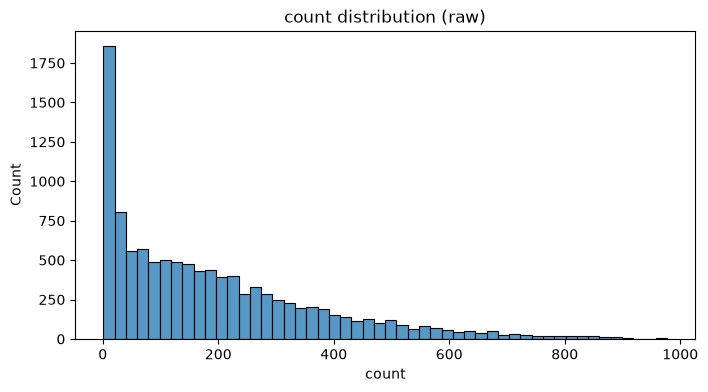

In [7]:
# count 분포 확인
plt.figure(figsize=(8, 4))
sns.histplot(df['count'], bins=50)
plt.title('count distribution (raw)')
plt.show()

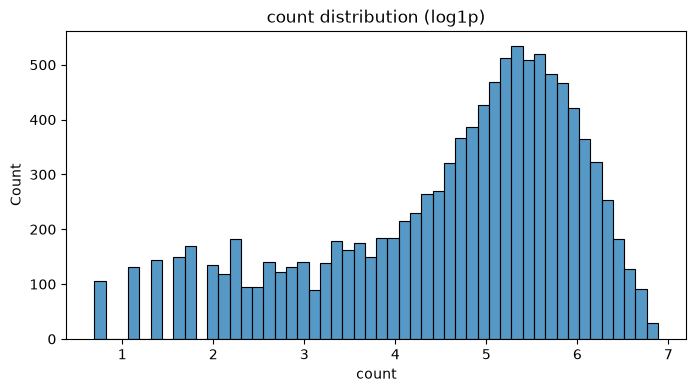

In [8]:
# log1p로 분포를 평평하게 만듬
log_count = np.log1p(df['count'])

plt.figure(figsize=(8, 4))
sns.histplot(log_count, bins=50)
plt.title('count distribution (log1p)')
plt.show()

In [9]:
print(df.describe())
df.isnull().sum()

             season       holiday    workingday       weather         temp  \
count  10886.000000  10886.000000  10886.000000  10886.000000  10886.00000   
mean       2.506614      0.028569      0.680875      1.418427     20.23086   
std        1.116174      0.166599      0.466159      0.633839      7.79159   
min        1.000000      0.000000      0.000000      1.000000      0.82000   
25%        2.000000      0.000000      0.000000      1.000000     13.94000   
50%        3.000000      0.000000      1.000000      1.000000     20.50000   
75%        4.000000      0.000000      1.000000      2.000000     26.24000   
max        4.000000      1.000000      1.000000      4.000000     41.00000   

              atemp      humidity     windspeed         count          year  \
count  10886.000000  10886.000000  10886.000000  10886.000000  10886.000000   
mean      23.655084     61.886460     12.799395    191.574132   2011.501929   
std        8.474601     19.245033      8.164537    181.14445

season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
count         0
year          0
month         0
day           0
hour          0
dtype: int64

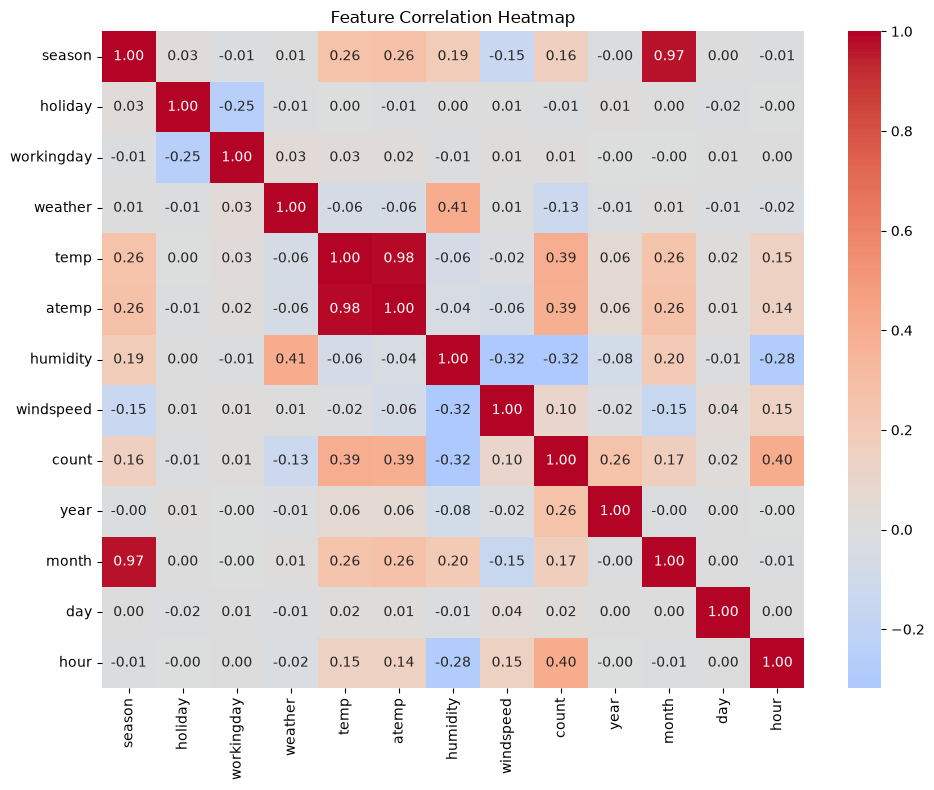

count         1.000000
hour          0.400601
temp          0.394454
atemp         0.389784
year          0.260403
month         0.166862
season        0.163439
windspeed     0.101369
day           0.019826
workingday    0.011594
holiday      -0.005393
weather      -0.128655
humidity     -0.317371
Name: count, dtype: float64

In [10]:
# 피처 간 상관관계 확인
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

corr['count'].sort_values(ascending=False)

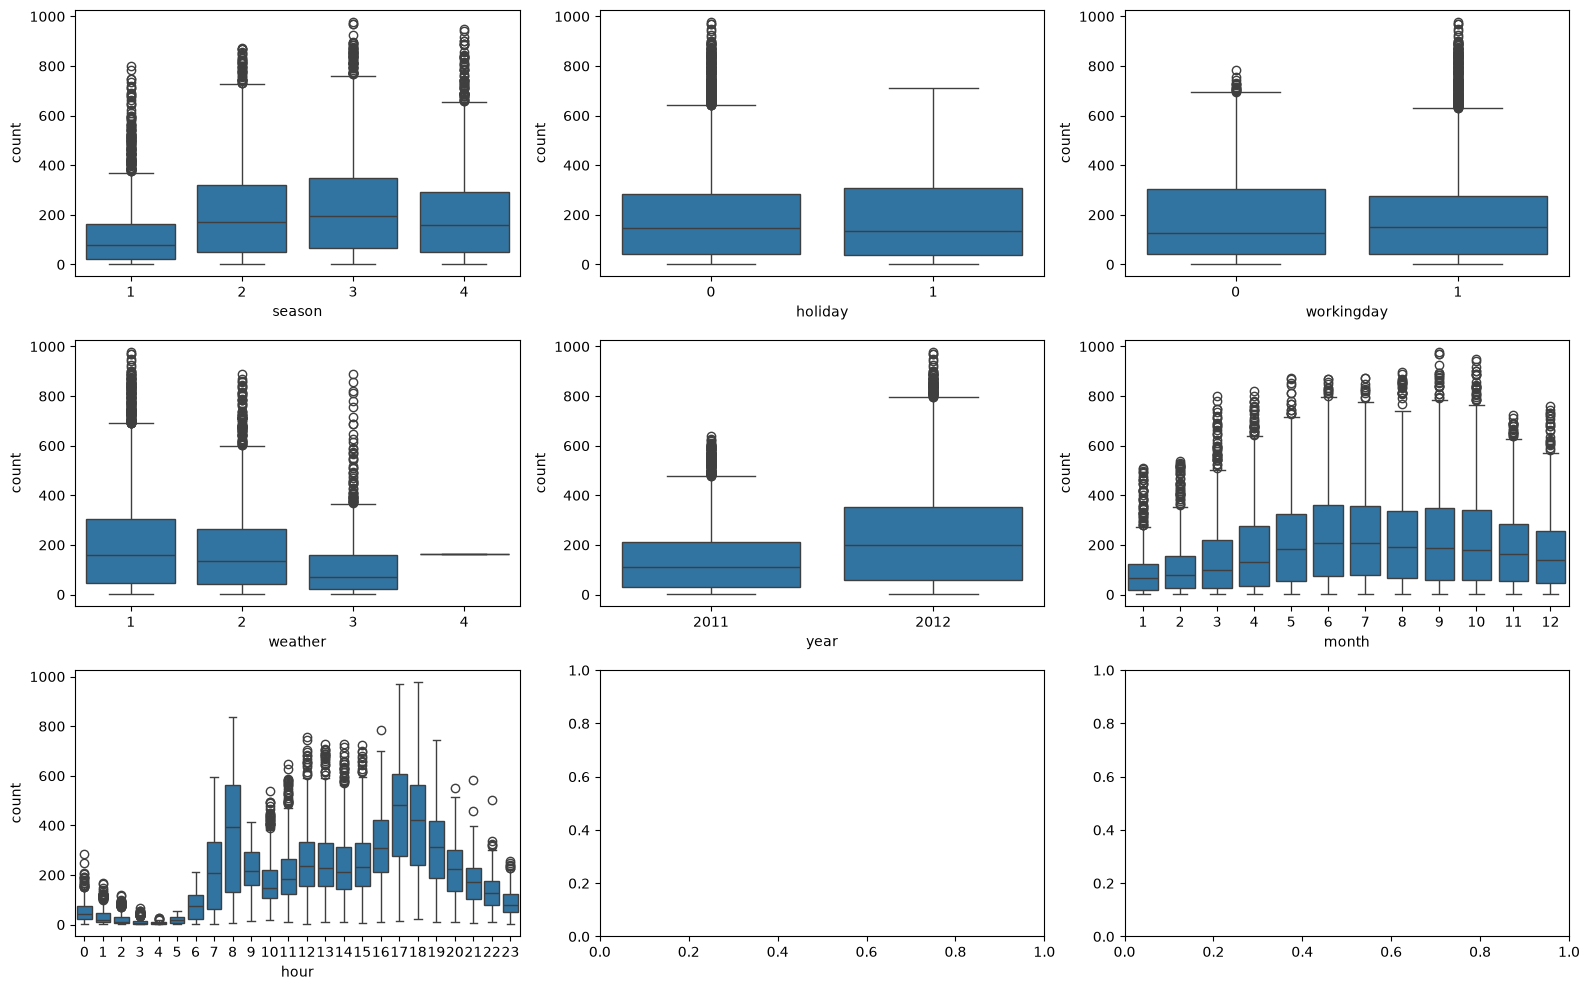

In [11]:
# boxplot으로 구간별 count 분포
features = ['season', 'holiday', 'workingday', 'weather', 'year', 'month', 'hour']

fig, axs = plt.subplots(figsize=(16, 10), ncols=3, nrows=3)
for i, feature in enumerate(features):
    row = int(i / 3)
    col = i % 3
    sns.boxplot(x=feature, y='count', data=df, ax=axs[row][col])

plt.tight_layout()
plt.show()

In [12]:
# 로그만으로는 만족스럽지 않아서 범주형 성격의 컬럼들을 get_dummies
dummies_cols = ['season', 'holiday', 'workingday', 'weather', 'year', 'month', 'day', 'hour']

y = log_count
X = df.drop(['count'], axis=1)

X_dum = pd.get_dummies(X, columns=dummies_cols)

print(X.shape)
print(X_dum.shape)
X_dum.head()

(10886, 12)
(10886, 73)


,temp,atemp,humidity,windspeed,season_1,season_2,season_3,season_4,holiday_0,holiday_1,...,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
0,9.84,14.395,81,0.0,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,9.02,13.635,80,0.0,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,9.02,13.635,80,0.0,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,9.84,14.395,75,0.0,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,9.84,14.395,75,0.0,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


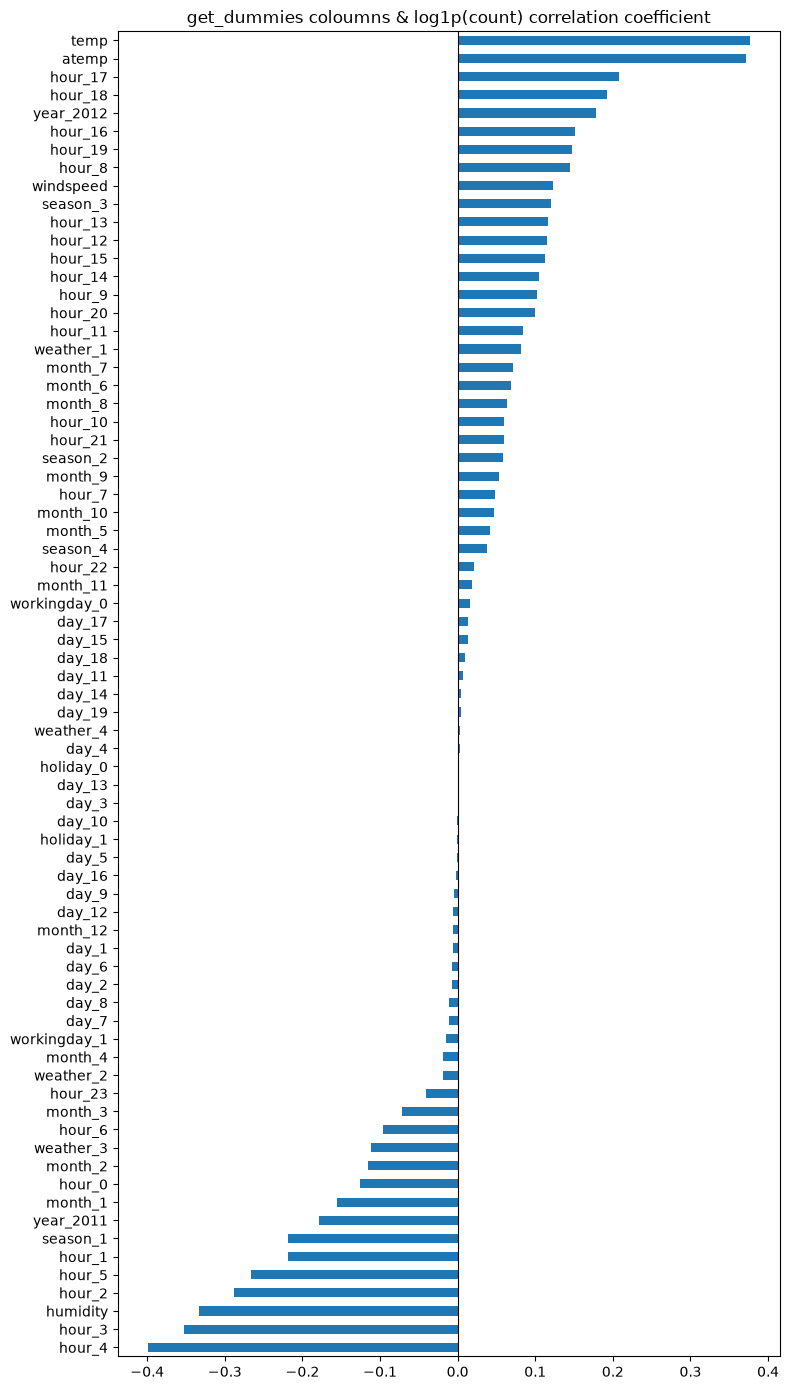

In [13]:
# 인코딩된 각 더미 컬럼이 타깃(log1p(count))과 얼마나 상관 있는지 막대 그래프로 확인
dummy_corr = X_dum.assign(log_count=np.log1p(df['count'])) \
                  .corr(numeric_only=True)['log_count'].drop('log_count').sort_values()

plt.figure(figsize=(8, 14))
dummy_corr.plot(kind='barh')
plt.title('get_dummies coloumns & log1p(count) correlation coefficient')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [14]:
X_train, X_val, y_train, y_val = train_test_split(X_dum, y, test_size=0.3, random_state=42)

print(X_train.shape)
print(X_val.shape)

(7620, 73)
(3266, 73)


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression

models = {
    'LinearRegression': LinearRegression(),
    'DecisionTree': DecisionTreeRegressor(random_state=42, max_depth=8),
    'RandomForest': RandomForestRegressor(random_state=42, n_estimators=200, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(random_state=42, n_estimators=200),
    'XGB': XGBRegressor(random_state=42, n_estimators=200),
    'LGBM': LGBMRegressor(random_state=42, n_estimators=200, verbose=-1)
}

cv_results = {}
for name, model in models.items():
    neg_mse_scores = cross_val_score(model, X_train, y_train, scoring='neg_mean_squared_error', cv=5)
    avg_rmse = np.sqrt(-neg_mse_scores).mean()
    cv_results[name] = avg_rmse
    print(f'{name:20s} avg RMSE(log): {avg_rmse:.4f}')

best_name = min(cv_results, key=cv_results.get)
print('\nBest model:', best_name, cv_results[best_name])

LinearRegression     avg RMSE(log): 0.5860
DecisionTree         avg RMSE(log): 0.7145
RandomForest         avg RMSE(log): 0.3597
GradientBoosting     avg RMSE(log): 0.4041
XGB                  avg RMSE(log): 0.3426
LGBM                 avg RMSE(log): 0.3237

Best model: LGBM 0.3236942980880139


In [16]:
from sklearn.metrics import mean_squared_error

# X_val로 실제 count 스케일에서 RMSE 확인
best_model = models[best_name]
best_model.fit(X_train, y_train)

pred_val_log = best_model.predict(X_val)

# 원래 count 스케일로 되돌려서(expm1) 평가
y_val_orig = np.expm1(y_val)
pred_val_orig = np.expm1(pred_val_log)

mse = mean_squared_error(y_val_orig, pred_val_orig)
rmse = np.sqrt(mse)
print('RMSE:', rmse)

RMSE: 45.37661520763731


In [21]:
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK

lgbm_space = {
    'n_estimators': hp.quniform('n_estimators', 100, 500, 50),
    'max_depth': hp.quniform('max_depth', 3, 10, 1),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
    'num_leaves': hp.quniform('num_leaves', 20, 60, 5),
}

def objective(params):
    model = LGBMRegressor(
        n_estimators=int(params['n_estimators']),
        max_depth=int(params['max_depth']),
        learning_rate=params['learning_rate'],
        num_leaves=int(params['num_leaves']),
        random_state=42, n_jobs=-1, verbose=-1,
    )
    neg_mse_scores = cross_val_score(model, X_train, y_train, scoring='neg_mean_squared_error', cv=3)
    avg_rmse = np.sqrt(-neg_mse_scores).mean()
    return {'loss': avg_rmse, 'status': STATUS_OK}

trials = Trials()
best_params = fmin(
    fn=objective,
    space=lgbm_space,
    algo=tpe.suggest,
    max_evals=30,
    trials=trials,
    rstate=np.random.default_rng(42),
    show_progressbar=False
)

best_params = {
    'n_estimators': int(best_params['n_estimators']),
    'max_depth': int(best_params['max_depth']),
    'learning_rate': best_params['learning_rate'],
    'num_leaves': int(best_params['num_leaves'])
}
print(best_params)

{'n_estimators': 450, 'max_depth': 9, 'learning_rate': np.float64(0.08435303281585022), 'num_leaves': 25}


In [18]:
tuned_model = LGBMRegressor(**best_params, random_state=42, n_jobs=-1, verbose=-1)
tuned_model.fit(X_train, y_train)

pred_val_log_tuned = tuned_model.predict(X_val)
pred_val_orig_tuned = np.expm1(pred_val_log_tuned)

mse_tuned = mean_squared_error(y_val_orig, pred_val_orig_tuned)
rmse_tuned = np.sqrt(mse_tuned)

print('튜닝 전 RMSE:', rmse)
print('튜닝 후 RMSE:', rmse_tuned)

튜닝 전 RMSE: 45.37661520763731
튜닝 후 RMSE: 47.40028591260315


In [22]:
final_model = LGBMRegressor(**best_params, random_state=42, n_jobs=-1, verbose=-1)
final_model.fit(X_dum, y)

UnicodeDecodeError: 'cp949' codec can't decode byte 0xe2 in position 2950: illegal multibyte sequence

UnicodeDecodeError: 'cp949' codec can't decode byte 0xe2 in position 2950: illegal multibyte sequence

LGBMRegressor(learning_rate=np.float64(0.08435303281585022), max_depth=9,
              n_estimators=450, n_jobs=-1, num_leaves=25, random_state=42,
              verbose=-1)

In [23]:
test_df = pd.read_csv('./data/bike_test.csv')
test_datetime = test_df['datetime']

test_df['datetime2'] = pd.to_datetime(test_df['datetime'])
test_df['year'] = test_df.datetime2.apply(lambda x: x.year)
test_df['month'] = test_df.datetime2.apply(lambda x: x.month)
test_df['day'] = test_df.datetime2.apply(lambda x: x.day)
test_df['hour'] = test_df.datetime2.apply(lambda x: x.hour)
test_df.drop(['datetime', 'datetime2'], axis=1, inplace=True)

X_test_dum = pd.get_dummies(test_df, columns=dummies_cols)
X_test_dum = X_test_dum.reindex(columns=X_dum.columns, fill_value=0)

print(X_test_dum.shape, X_dum.shape)
X_test_dum.head()

(6493, 73) (10886, 73)


,temp,atemp,humidity,windspeed,season_1,season_2,season_3,season_4,holiday_0,holiday_1,...,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
0,10.66,11.365,56,26.0027,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,10.66,13.635,56,0.0000,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,10.66,13.635,56,0.0000,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,10.66,12.880,56,11.0014,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,10.66,12.880,56,11.0014,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


In [24]:
pred_log = final_model.predict(X_test_dum)
pred_count = np.expm1(pred_log)
pred_count = np.clip(pred_count, 0, None)

submission = pd.DataFrame({'datetime': test_datetime, 'count': pred_count})
submission.to_csv('./data/bike_submission.csv', index=False)

print(submission.shape)
submission.head()

(6493, 2)


,datetime,count
0,2011-01-20 00:00:00,10.175737
1,2011-01-20 01:00:00,3.804378
2,2011-01-20 02:00:00,2.802335
3,2011-01-20 03:00:00,3.970736
4,2011-01-20 04:00:00,1.789978
